In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("cleaned_flight_delay.csv")

In [3]:
df.head()

,Year,Month,AirlineCode,AirportCode,TotalFlights,FlightsDelayedOver15Min,CarrierDelayCount,WeatherDelayCount,NASDelayCount,SecurityDelayCount,LateAircraftDelayCount,CancelledFlights,DivertedFlights,ArrivalDelayMinutes,Delayed
0,2022,7,0,0,33.0,2.0,0.92,1.00,0.08,0.0,0.00,0.0,0.0,129.0,1
1,2022,7,0,4,78.0,25.0,11.80,0.72,5.01,0.0,7.48,0.0,0.0,1664.0,1
2,2022,7,0,5,124.0,19.0,5.84,1.00,6.76,0.0,5.40,5.0,4.0,1523.0,1
3,2022,7,0,11,67.0,10.0,1.32,1.00,2.40,1.0,4.28,0.0,1.0,657.0,1
4,2022,7,0,12,174.0,30.0,18.10,5.75,3.60,0.0,2.55,1.0,0.0,2462.0,1


In [4]:
X = df.drop(["ArrivalDelayMinutes", "Delayed"], axis=1)

In [5]:
y = df["ArrivalDelayMinutes"]

In [6]:
y.shape

(100960,)

In [7]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80768, 13)
(20192, 13)
(80768,)
(20192,)


In [11]:
from sklearn.ensemble import RandomForestRegressor

In [12]:
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [13]:
rf_regressor.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
y_pred = rf_regressor.predict(X_test)

In [15]:
print(y_pred[:10])

[ 1693.75  4549.98  1113.86 18800.65  1154.82  6195.48   254.11  1448.1
  1779.53  4486.14]


In [16]:
from sklearn.metrics import mean_absolute_error

In [17]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 545.4277971473851


In [18]:
from sklearn.metrics import mean_squared_error

In [19]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 3081140.6089588255


In [20]:
from sklearn.metrics import root_mean_squared_error

In [21]:
import numpy as np

In [22]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 1755.3178085346326


In [23]:
from sklearn.metrics import r2_score

In [24]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9786593283801988


In [25]:
comparison = pd.DataFrame({
    "Actual Delay (Minutes)": y_test.values,
    "Predicted Delay (Minutes)": y_pred
})

comparison.head(10)

,Actual Delay (Minutes),Predicted Delay (Minutes)
0,1379.0,1693.75
1,4697.0,4549.98
2,617.0,1113.86
3,18606.0,18800.65
4,945.0,1154.82
5,5224.0,6195.48
6,242.0,254.11
7,1768.0,1448.10
8,1559.0,1779.53
9,3819.0,4486.14


In [26]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


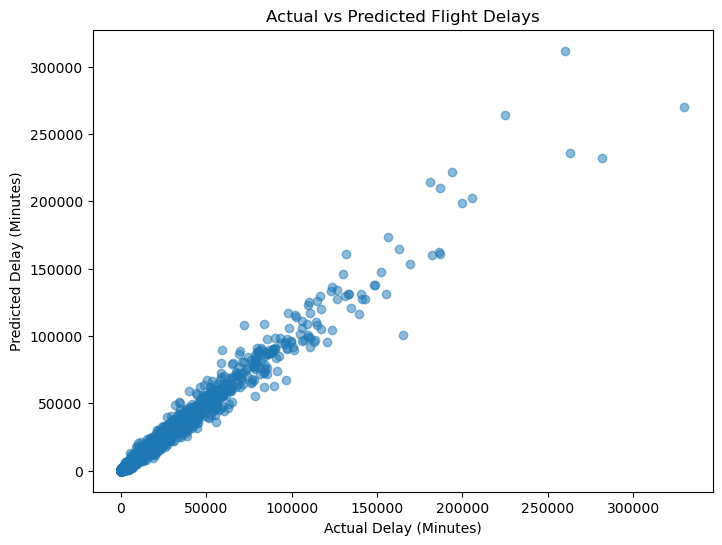

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Delay (Minutes)")
plt.ylabel("Predicted Delay (Minutes)")
plt.title("Actual vs Predicted Flight Delays")

plt.show()

In [28]:
correlation = df.corr(numeric_only=True)["ArrivalDelayMinutes"].sort_values(ascending=False)

print(correlation)

ArrivalDelayMinutes        1.000000
FlightsDelayedOver15Min    0.968492
LateAircraftDelayCount     0.918834
CarrierDelayCount          0.895217
NASDelayCount              0.893487
TotalFlights               0.873379
WeatherDelayCount          0.797164
DivertedFlights            0.724365
SecurityDelayCount         0.431358
CancelledFlights           0.342448
Delayed                    0.075160
AirlineCode                0.015545
Month                     -0.003591
AirportCode               -0.024358
Year                      -0.042670
Name: ArrivalDelayMinutes, dtype: float64


In [29]:
print(df["ArrivalDelayMinutes"].describe())

count    100960.000000
mean       3824.531220
std       11725.452846
min           0.000000
25%         268.000000
50%         869.000000
75%        2525.000000
max      429194.000000
Name: ArrivalDelayMinutes, dtype: float64


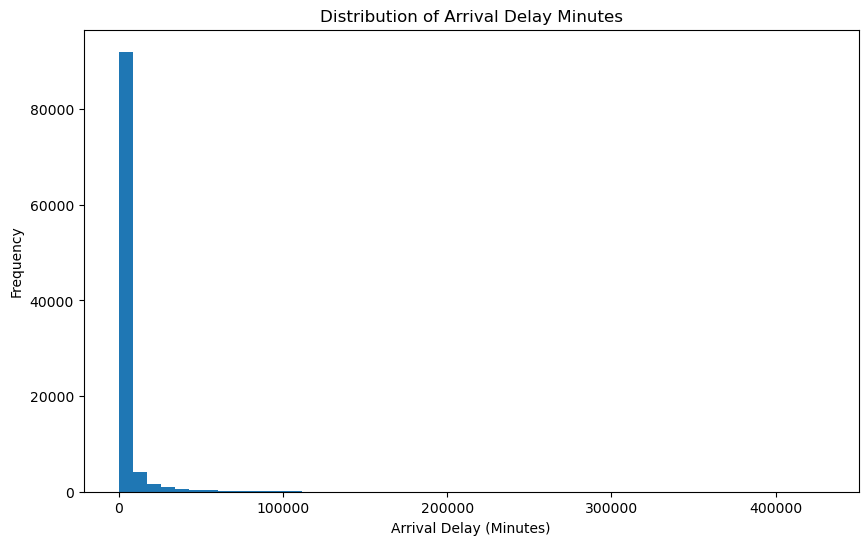

In [30]:
plt.figure(figsize=(10, 6))

plt.hist(df["ArrivalDelayMinutes"], bins=50)

plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Arrival Delay Minutes")

plt.show()

In [31]:
import numpy as np

df["LogArrivalDelay"] = np.log1p(df["ArrivalDelayMinutes"])

print(df["LogArrivalDelay"].describe())

count    100960.000000
mean          6.543775
std           2.182630
min           0.000000
25%           5.594711
50%           6.768493
75%           7.834392
max          12.969667
Name: LogArrivalDelay, dtype: float64


In [33]:
print("Regression Model Results")
print("------------------------")
print("Model: Random Forest Regressor")
print("MAE:", round(mae, 2), "minutes")
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2), "minutes")
print("R² Score:", round(r2, 4))

Regression Model Results
------------------------
Model: Random Forest Regressor
MAE: 545.43 minutes
MSE: 3081140.61
RMSE: 1755.32 minutes
R² Score: 0.9787


In [34]:
print("========== MODEL COMPARISON ==========")

print("\nBinary Classification")
print("----------------------")
print("Random Forest Accuracy: 99.77%")
print("KNN Accuracy: 94.70%")
print("SVM Accuracy: 95.12%")

print("\nRegression")
print("----------------------")
print("Random Forest Regressor R²:", 0.9787)
print("Random Forest Regressor MAE:", 545.43, "minutes")
print("Random Forest Regressor RMSE:", 1755.32, "minutes")

========== MODEL COMPARISON ==========

Binary Classification
----------------------
Random Forest Accuracy: 99.77%
KNN Accuracy: 94.70%
SVM Accuracy: 95.12%

Regression
----------------------
Random Forest Regressor R²: 0.9787
Random Forest Regressor MAE: 545.43 minutes
Random Forest Regressor RMSE: 1755.32 minutes


In [35]:
import joblib

In [36]:
joblib.dump(rf_regressor, "random_forest_regressor.pkl")

['random_forest_regressor.pkl']

In [37]:
import joblib

loaded_regressor = joblib.load("random_forest_regressor.pkl")

print(type(loaded_regressor))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [38]:
y_pred_loaded = load-z ed_regressor.predict(X_test)

print(y_pred_loaded[:10])

[ 1693.75  4549.98  1113.86 18800.65  1154.82  6195.48   254.11  1448.1
  1779.53  4486.14]
